## Create a single, three-panel figure summarizing the DepMap dataset

| Panel | Description | Importance | Plot type |
| :---: | :---------: | :--------: | :-------: |
| A     | Distribution of cancer types (all models) | View diversity of cancer types profiled | Bar |
| B     | Distribution of ages | How many pediatric vs adult cancers | Histogram |
| C     | Distribution of pediatric cancer types by sex | View how many pediatric cancer types of each | Bar |

In [1]:
suppressPackageStartupMessages(library(dplyr))
suppressPackageStartupMessages(library(ggplot2))
suppressPackageStartupMessages(library(cowplot))
suppressPackageStartupMessages(library(arrow))

In [2]:
# Set i/o paths and files
data_dir <- file.path("../0.data-download/data")
fig_dir <- file.path("figures")

model_input_file <- file.path(data_dir, "Model.parquet")
crispr_input_file <- file.path(data_dir, "CRISPRGeneEffect.parquet")

figure_output_file <- file.path(fig_dir, "cancer_type_age_and_ped_model_distributions.png")

In [3]:
# Set figure sizes
text_size = 9

In [4]:
# Load arrow package
library(arrow)

# Process dataset using arrow
model_df <- arrow::read_parquet(
    model_input_file
)

print(dim(model_df))

crispr_df <- arrow::read_parquet(
    crispr_input_file
)

print(dim(crispr_df))

# Get common depmap identifiers
common_depmap_ids <- intersect(model_df$ModelID, crispr_df$ModelID)

# Subset the model dataframe to only those we have dependency data for
model_df <- model_df %>%
    dplyr::filter(ModelID %in% common_depmap_ids)

# The updated dimensions should be the same as crispr_df
print(dim(model_df))

# Show model_df
head(model_df, 3)

[1] 1959   43


[1]  1150 18444


[1] 1150   43


ModelID,PatientID,CellLineName,StrippedCellLineName,DepmapModelType,OncotreeLineage,OncotreePrimaryDisease,OncotreeSubtype,OncotreeCode,LegacyMolecularSubtype,⋯,EngineeredModel,TissueOrigin,ModelDerivationMaterial,PublicComments,CCLEName,HCMIID,WTSIMasterCellID,SangerModelID,COSMICID,DateSharedIndbGaP
<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,⋯,<chr>,<dbl>,<chr>,<chr>,<chr>,<chr>,<dbl>,<chr>,<dbl>,<dbl>
ACH-000001,PT-gj46wT,NIH:OVCAR-3,NIHOVCAR3,HGSOC,Ovary/Fallopian Tube,Ovarian Epithelial Tumor,High-Grade Serous Ovarian Cancer,HGSOC,NA,⋯,NA,NA,NA,NA,NIHOVCAR3_OVARY,NA,2201,SIDM00105,905933,NA
ACH-000004,PT-q4K2cp,HEL,HEL,AML,Myeloid,Acute Myeloid Leukemia,Acute Myeloid Leukemia,AML,NA,⋯,NA,NA,NA,NA,HEL_HAEMATOPOIETIC_AND_LYMPHOID_TISSUE,NA,783,SIDM00594,907053,NA
ACH-000005,PT-q4K2cp,HEL 92.1.7,HEL9217,AML,Myeloid,Acute Myeloid Leukemia,Acute Myeloid Leukemia,AML,NA,⋯,NA,NA,NA,NA,HEL9217_HAEMATOPOIETIC_AND_LYMPHOID_TISSUE,NA,NA,SIDM00593,NA,NA


In [5]:
colnames(model_df)

[1] "ModelID"                  "PatientID"               
 [3] "CellLineName"             "StrippedCellLineName"    
 [5] "DepmapModelType"          "OncotreeLineage"         
 [7] "OncotreePrimaryDisease"   "OncotreeSubtype"         
 [9] "OncotreeCode"             "LegacyMolecularSubtype"  
[11] "LegacySubSubtype"         "PatientMolecularSubtype" 
[13] "RRID"                     "Age"                     
[15] "AgeCategory"              "Sex"                     
[17] "PatientRace"              "PrimaryOrMetastasis"     
[19] "SampleCollectionSite"     "SourceType"              
[21] "SourceDetail"             "CatalogNumber"           
[23] "PatientTreatmentStatus"   "PatientTreatmentType"    
[25] "PatientTreatmentDetails"  "Stage"                   
[27] "StagingSystem"            "PatientTumorGrade"       
[29] "PatientTreatmentResponse" "GrowthPattern"           
[31] "OnboardedMedia"           "FormulationID"           
[33] "PlateCoating"             "EngineeredModel"         
[35] "TissueOrigin"             "ModelDerivationMaterial" 
[37] "PublicComments"           "CCLEName"                
[39] "HCMIID"                   "WTSIMasterCellID"        
[41] "SangerModelID"            "COSMICID"                
[43] "DateSharedIndbGaP"

## Cancer type distribution (all models)

In [6]:
# Fold a rare mixed-histology liver entity into Hepatocellular Carcinoma
model_df <- model_df %>%
    dplyr::mutate(
        OncotreePrimaryDisease = dplyr::recode(
            OncotreePrimaryDisease,
            `Hepatocellular Carcinoma plus Intrahepatic Cholangiocarcinoma` = "Hepatocellular Carcinoma"
        )
    )

# Determine the distribution of cancer types (OncotreePrimaryDisease) across
# all models with CRISPR dependency data.
# - Non-cancerous control lines get their own explicit category.
# - The n_top most common cancer types are shown individually.
# - Among the remaining rare types, lineages (tissue of origin) with at least
#   lineage_min_count models are grouped into their own "Other/Rare <Lineage>"
#   category (with the number of unique disease types folded in, in
#   parentheses).
# - All smaller lineages collapse into a single generic "Other/Rare" category.
n_top <- 15
lineage_min_count <- 15

disease_counts <- model_df %>%
    dplyr::filter(OncotreePrimaryDisease != "Non-Cancerous") %>%
    dplyr::count(OncotreePrimaryDisease, sort = TRUE)

print(paste("Total unique cancer types:", nrow(disease_counts)))

top_diseases <- disease_counts$OncotreePrimaryDisease[seq_len(n_top)]

lineage_counts <- model_df %>%
    dplyr::filter(
        !(OncotreePrimaryDisease %in% top_diseases),
        OncotreePrimaryDisease != "Non-Cancerous"
    ) %>%
    dplyr::group_by(OncotreeLineage) %>%
    dplyr::summarize(
        n_models = dplyr::n(),
        n_types = dplyr::n_distinct(OncotreePrimaryDisease),
        .groups = "drop"
    )

named_lineages <- lineage_counts %>%
    dplyr::filter(n_models >= lineage_min_count)

lineage_label <- setNames(
    paste0("Other/Rare ", named_lineages$OncotreeLineage, " (", named_lineages$n_types, " unique)"),
    named_lineages$OncotreeLineage
)

catchall_n_types <- model_df %>%
    dplyr::filter(
        !(OncotreePrimaryDisease %in% top_diseases),
        OncotreePrimaryDisease != "Non-Cancerous",
        !(OncotreeLineage %in% named_lineages$OncotreeLineage)
    ) %>%
    dplyr::pull(OncotreePrimaryDisease) %>%
    dplyr::n_distinct()

model_df <- model_df %>%
    dplyr::mutate(
        disease_type_recoded = dplyr::case_when(
            OncotreePrimaryDisease == "Non-Cancerous" ~ "Non-Cancerous",
            OncotreePrimaryDisease %in% top_diseases ~ OncotreePrimaryDisease,
            OncotreeLineage %in% names(lineage_label) ~ lineage_label[OncotreeLineage],
            TRUE ~ paste0("Other/Rare (", catchall_n_types, " unique)")
        )
    )

model_df$disease_type_recoded <- factor(
    model_df$disease_type_recoded,
    levels = names(sort(rev(table(model_df$disease_type_recoded))))
)

[1] "Total unique cancer types: 73"


Warning message:
“A numeric `legend.position` argument in `theme()` was deprecated in ggplot2
3.5.0.
ℹ Please use the `legend.position.inside` argument of `theme()` instead.”


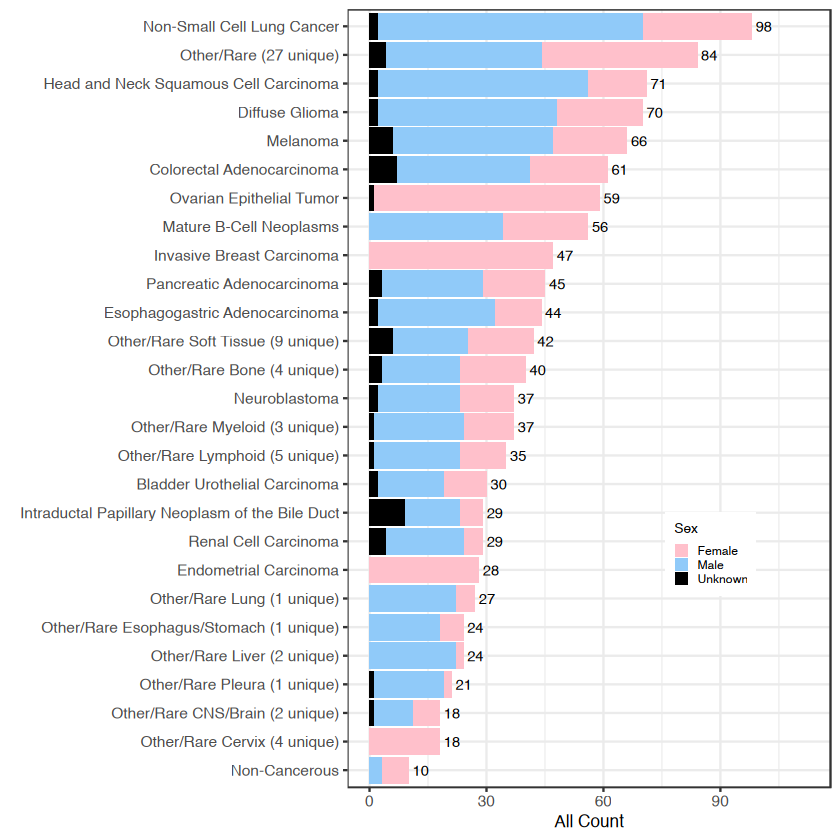

In [7]:
all_cancer_type_distrib_gg = (
    ggplot(model_df, aes(x = disease_type_recoded))
    + geom_bar(aes(fill = Sex), position = "stack")
    + coord_flip()
    + theme_bw()
    + geom_text(
        stat = "count",
        aes(label = after_stat(count)),
        vjust = 0.5,
        hjust = -0.25,
        size = 3
    )
    + scale_fill_manual(
        values = c(
            "Male" = "#90CAF9",
            "Female" = "pink",
            "Unknown" = "black"
        )
    )
    + ylim(c(0, max(table(model_df$disease_type_recoded)) * 1.15))
    + theme(
        axis.text = element_text(size = text_size),
        axis.title = element_text(size = text_size + 1),
        legend.text = element_text(size = text_size - 2),
        legend.title = element_text(size = text_size - 1),
        legend.position = c(0.75, 0.3),
        legend.key.size = unit(0.3, 'cm')
    )
    + labs(y = "All Count", x = "")
    + guides(fill = guide_legend(override.aes = list(size = 0.5)))
)

all_cancer_type_distrib_gg

## Age distribution

`stat_bin()` using `bins = 30`. Pick better value with `binwidth`.


Warning message:
“Removed 217 rows containing non-finite outside the scale range (`stat_bin()`).”


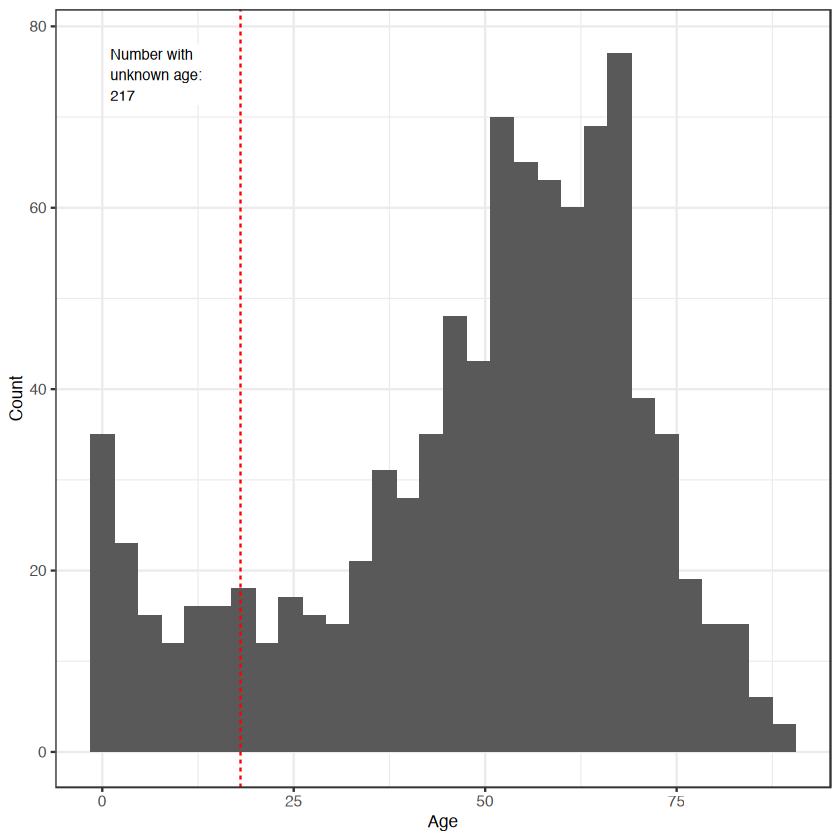

In [8]:
n_unknown_age <- sum(is.na(model_df$Age))

age_distrib_gg = (
    ggplot(model_df, aes(x = Age))
    + geom_histogram()
    + geom_vline(xintercept = 18, linetype = "dashed", color = "red")
    + annotate(
        "label",
        x = 0.5, y = 78,
        label = paste0("Number with\nunknown age:\n", n_unknown_age),
        hjust = 0, vjust = 1,
        size = 3,
        fill = "white",
        label.size = 0
    )
    + theme_bw()
    + theme(
        axis.text = element_text(size = text_size),
        axis.title = element_text(size = text_size + 1)
    )
    + labs(y = "Count")
)

age_distrib_gg

In [9]:
# Subset to pediatric cancers only
ped_model_df <- model_df %>%
    dplyr::filter(AgeCategory == "Pediatric")

In [10]:
rev(sort(table(ped_model_df$OncotreePrimaryDisease)))


                                                                                      Neuroblastoma 
                                                                                                 35 
                                                                                      Ewing Sarcoma 
                                                                                                 15 
                                                                                    Embryonal Tumor 
                                                                                                 14 
                                                                                   Rhabdomyosarcoma 
                                                                                                 13 
                                                                                       Osteosarcoma 
                                                                                          

In [11]:
disease_type_recode <- ped_model_df$OncotreePrimaryDisease %>%
    dplyr::recode(
        `Diffuse Glioma` = "Other/Rare (13 unique)",
        `Epithelioid Sarcoma` = "Other/Rare (13 unique)",
        `Melanoma` = "Other/Rare (13 unique)",
        `Myeloproliferative Neoplasms` = "Other/Rare (13 unique)",
        `Ovarian Epithelial Tumor` = "Other/Rare (13 unique)",
        `Ovarian Germ Cell Tumor` = "Other/Rare (13 unique)",
        `Undifferentiated Pleomorphic Sarcoma/Malignant Fibrous Histiocytoma/High-Grade Spindle Cell Sarcoma` = "Other/Rare (13 unique)",
        `Hepatoblastoma` = "Other/Rare (13 unique)",
        `Renal Cell Carcinoma` = "Other/Rare (13 unique)",
        `Retinoblastoma` = "Other/Rare (13 unique)",
        `Rhabdoid Cancer` = "Other/Rare (13 unique)",
        `Synovial Sarcoma` = "Other/Rare (13 unique)",
        `T-Lymphoblastic Leukemia/Lymphoma` = "Other/Rare (13 unique)",
        `B-Lymphoblastic Leukemia/Lymphoma` = "B-ALL"
    )

ped_model_df <- ped_model_df %>%
    dplyr::mutate(disease_type_recoded = disease_type_recode)

ped_model_df$disease_type_recoded <- factor(
    ped_model_df$disease_type_recoded,
    levels = names(sort(rev(table(ped_model_df$disease_type_recoded))))
)

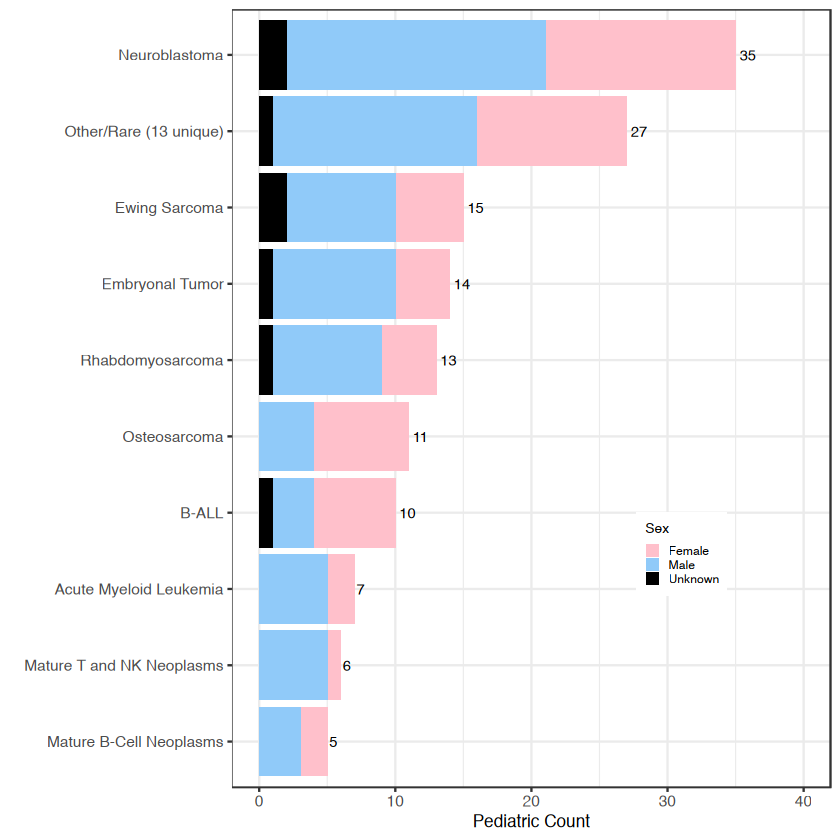

In [12]:
ped_cancer_type_distrib_gg = (
    ggplot(ped_model_df, aes(x = disease_type_recoded))
    + geom_bar(aes(fill = Sex), position = "stack")
    + coord_flip()
    + theme_bw()
    + geom_text(
        stat = "count",
        aes(label = after_stat(count)),
        vjust = 0.5,
        hjust = -0.25,
        size = 3
    )
    + scale_fill_manual(
        values = c(
            "Male" = "#90CAF9",
            "Female" = "pink",
            "Unknown" = "black"
        )
    )
    + ylim(c(0, 40))
    + theme(
        axis.text = element_text(size = text_size),
        axis.title = element_text(size = text_size + 1),
        legend.text = element_text(size = text_size - 2),
        legend.title = element_text(size = text_size - 1),
        legend.position = c(0.75, 0.3),
        legend.key.size = unit(0.3, 'cm')
    )
    + labs(y = "Pediatric Count", x = "")
    + guides(fill = guide_legend(override.aes = list(size = 0.5)))
)

ped_cancer_type_distrib_gg

`stat_bin()` using `bins = 30`. Pick better value with `binwidth`.


Warning message:
“Removed 217 rows containing non-finite outside the scale range (`stat_bin()`).”


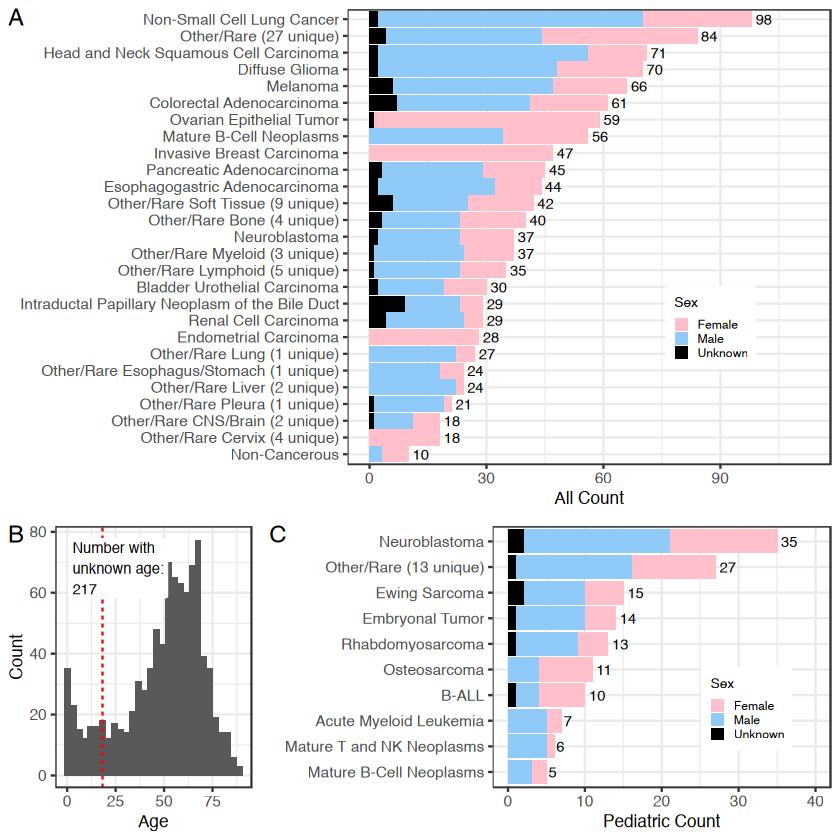

In [13]:
top_row <- cowplot::plot_grid(
    all_cancer_type_distrib_gg,
    labels = c("A")
)

bottom_row <- cowplot::plot_grid(
    age_distrib_gg,
    ped_cancer_type_distrib_gg,
    labels = c("B", "C"),
    ncol = 2,
    rel_widths = c(0.45, 1)
)

full_gg <- cowplot::plot_grid(
    top_row,
    bottom_row,
    ncol = 1,
    rel_heights = c(1.6, 1)
)

ggsave(figure_output_file, full_gg, width = 7, height = 7.5, dpi = 500)

full_gg